# SVM Classifier on Baseline Dataset
We use SVM to predict Sepsis from vital signal, lab test, and demographics data.

## Assistant Functions

In [1]:
def concat_patients(train_dir, patient_list):
    """
    Concatenate individual patient dataframes for
    the training, valid, or other dataframes.
    """
    p = pd.read_csv(train_dir + '/' + patient_list[0], sep="|")
    p['patient_id'] = patient_list[0][1:7]
    for i in range(1, len(patient_list)):
        p_n = pd.read_csv(train_dir + '/' + patient_list[i], sep="|")
        p_n['patient_id'] = patient_list[i][1:7]
        p = pd.concat([p, p_n])
    return p

def predictors_labels_allocator(df):
    """Allocate predictors and labels."""
    col_names = df.columns
    X = np.array(df[col_names[:-2]].values)
    y = df[col_names[-2]].values
    return X, y

def F(beta, precision, recall):
    """Calculate f-beta score."""
    return (beta*beta + 1)*precision*recall / (beta*beta*precision + recall)

## Load the data
Import standard modules.

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib

from sklearn import preprocessing
from sklearn.metrics import (precision_recall_curve, auc, roc_curve,
                             precision_score, recall_score, accuracy_score)
from sklearn.model_selection import GridSearchCV
from plot_metric.functions import BinaryClassification
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

In [3]:
train_dir = './../Data/training_setA/baseline/train_baseline/'
valid_dir = './../Data/training_setA/baseline/val_baseline/'
test_dir  = './../Data/training_setA/baseline/test_baseline/'

TRAIN_PATH = train_dir + 'data_baseline_train.parquet'
VALID_PATH = valid_dir + 'data_baseline_valid.parquet'
TEST_PATH  = test_dir  + 'data_baseline_test.parquet'

tr_patients  = sorted(os.listdir(train_dir))
vld_patients = sorted(os.listdir(valid_dir))
ts_patients  = sorted(os.listdir(test_dir))

print('num training patients:', len(tr_patients))
print('num valid patients:',    len(vld_patients))
print('num test patients:',     len(ts_patients))

num training patients: 14237
num valid patients: 3051
num test patients: 3051


Concatenate patients into `train_df`, `valid_df`, and `test_df`.

In [4]:
try:
    if not all(os.path.exists(p) for p in [TRAIN_PATH, VALID_PATH, TEST_PATH]):
        raise FileNotFoundError("One or more parquet files missing")
    train_df = pd.read_parquet(TRAIN_PATH)
    valid_df = pd.read_parquet(VALID_PATH)
    test_df  = pd.read_parquet(TEST_PATH)
    print("Loaded data from parquet files")
except Exception as e:
    print(e)
    print("Creating new parquet files...")
    train_df = concat_patients(train_dir, tr_patients)
    valid_df = concat_patients(valid_dir, vld_patients)
    test_df  = concat_patients(test_dir,  ts_patients)
    train_df.to_parquet(TRAIN_PATH, index=False)
    valid_df.to_parquet(VALID_PATH, index=False)
    test_df.to_parquet(TEST_PATH,  index=False)
    print("Saved data to parquet files")

Loaded data from parquet files


Check missing data.

In [5]:
print('train data has missing values:', train_df.isnull().sum().sum() != 0)
print('valid data has missing values:', valid_df.isnull().sum().sum() != 0)
print('test data has missing values:', test_df.isnull().sum().sum() != 0)

train data has missing values: False
valid data has missing values: False
test data has missing values: False


## SVM Classification for Sepsis
Separate features (X) and labels (y), then fit the model on training data.

In [6]:
Xtr,  ytr  = predictors_labels_allocator(train_df)
Xvld, yvld = predictors_labels_allocator(valid_df)
Xts,  yts  = predictors_labels_allocator(test_df)

Define and fit a `StandardScaler` on training data.

In [7]:
scaler = preprocessing.StandardScaler()
scaler.fit(Xtr)
Xtr  = scaler.transform(Xtr)
Xvld = scaler.transform(Xvld)
Xts  = scaler.transform(Xts)

Create a `SVM` model and fit on training data.

In [8]:
MODEL_PATH = "./../Data/svm_baseline_model.joblib"

try:
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError("Model file not found")
    model = joblib.load(MODEL_PATH)
    print("Loaded model from disk")

except Exception as e:
    print(e)
    print("Training new model...")
    model = LinearSVC(C=1.0, random_state=42, class_weight='balanced')
    model.fit(Xtr, ytr)
    joblib.dump(model, MODEL_PATH)
    print(f"Model saved to {MODEL_PATH}")

Model file not found
Training new model...
Model saved to ./../Data/svm_baseline_model.joblib


Measure validation accuracy.

In [9]:
yhat = model.predict(Xvld)
acc = np.mean(yhat == yvld)
print('Accuracy on the validation data is {0:f}'.format(acc))

Accuracy on the validation data is 0.772614


## Feature Importance

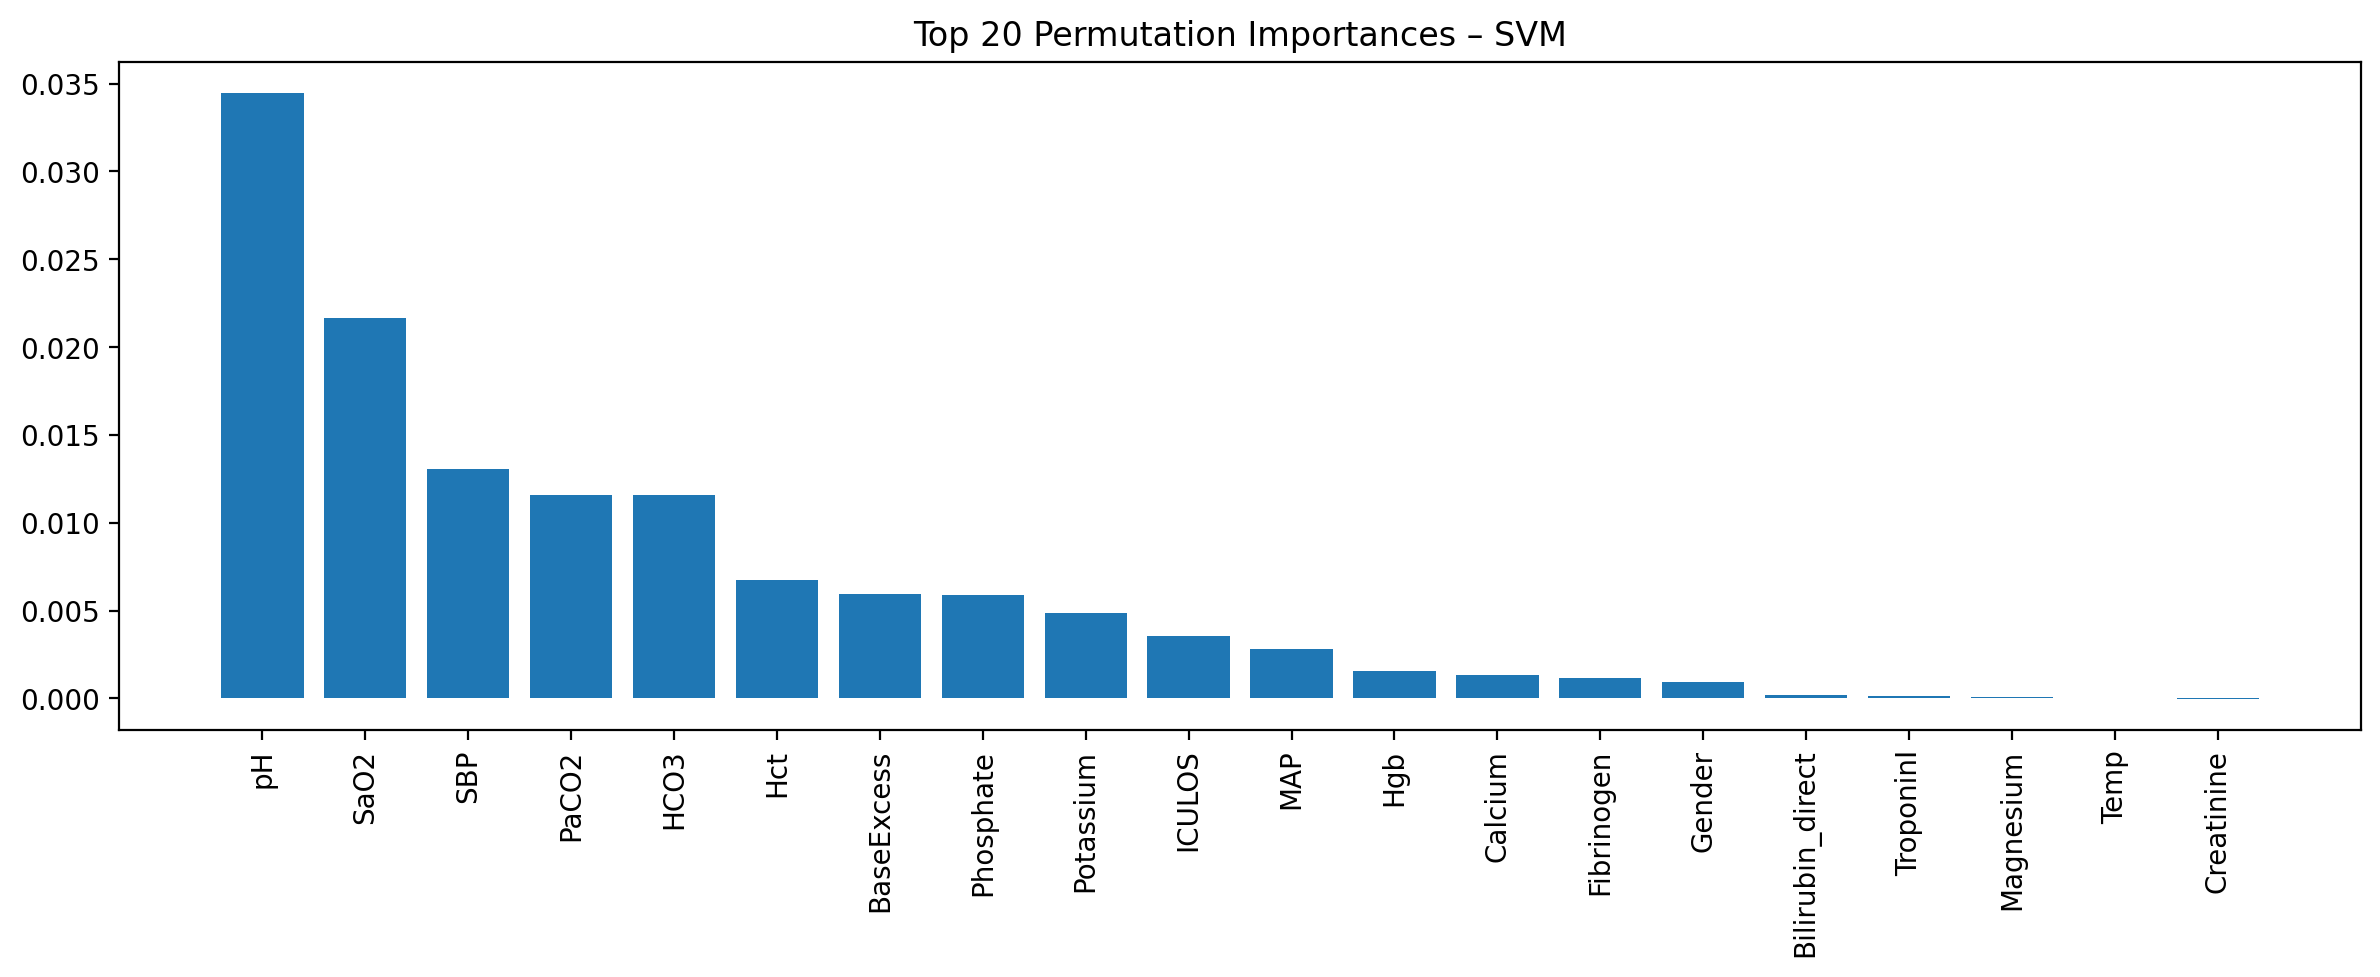

Top 4 most significant features:
  1. pH
  2. SaO2
  3. SBP
  4. PaCO2


In [10]:
# SVM does not provide feature importances directly.
# We approximate importance via the absolute values of the decision function coefficients
# (only available for linear kernel). For RBF we show a permutation-importance proxy.
from sklearn.inspection import permutation_importance

result = permutation_importance(model, Xvld, yvld, n_repeats=10, random_state=42, n_jobs=-1)
feature_names = list(train_df.columns[:-2])
indices = np.argsort(result.importances_mean)[::-1]

plt.figure(figsize=(12, 5))
plt.title("Top 20 Permutation Importances – SVM")
plt.bar(range(20), result.importances_mean[indices[:20]])
plt.xticks(range(20), [feature_names[i] for i in indices[:20]], rotation=90)
plt.tight_layout()
plt.show()

print("Top 4 most significant features:")
for k in range(4):
    print(f"  {k+1}. {feature_names[indices[k]]}")

## Hyperparameter Tuning
Use `GridSearchCV` to find optimal hyperparameters.

In [11]:
from sklearn.svm import SVC

model_tune = SVC(probability=True, random_state=42)

hyperparameters = {
    'C':      [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale', 'auto'],
}

In [12]:
print(Xtr.shape)

(552839, 37)


In [13]:
from sklearn.utils import resample

MAX_SAMPLES = 5000000

CLF_PATH        = "./../Data/svm_tuning_clf.joblib"
BEST_MODEL_PATH = "./../Data/svm_tuning_best_model.joblib"
FINAL_MODEL_PATH = "./../Data/svm_final_model.joblib"

try:
    if not all(os.path.exists(p) for p in [CLF_PATH, BEST_MODEL_PATH, FINAL_MODEL_PATH]):
        raise FileNotFoundError("One or more joblib files missing")
    clf         = joblib.load(CLF_PATH)
    best_model  = joblib.load(BEST_MODEL_PATH)
    final_model = joblib.load(FINAL_MODEL_PATH)
    print("Loaded clf, best model, and final model from joblib files")

except Exception as e:
    print(e)
    print("Error opening files, creating new...")

    # Subsample for grid search
    
    if len(Xtr) > MAX_SAMPLES:
        Xtr_sub, ytr_sub = resample(Xtr, ytr, n_samples=MAX_SAMPLES,
                                     stratify=ytr, random_state=42)
    else:
        Xtr_sub, ytr_sub = Xtr, ytr
        print(f"Grid search using {len(Xtr_sub)} samples instead of {len(Xtr)}")

    # Grid search on subsample
    model_tune = LinearSVC(random_state=42, class_weight='balanced')
    hyperparameters = {
        'C':     [0.1, 1, 10],
        #'gamma': ['scale', 'auto'],
    }
    clf        = GridSearchCV(model_tune, hyperparameters, cv=3, verbose=1,
                              n_jobs=-1, scoring='roc_auc')
    best_model = clf.fit(Xtr_sub, ytr_sub)
    print("Best params:", best_model.best_params_)

    # Retrain best params on full training data
    final_model = LinearSVC(**best_model.best_params_,
                      random_state=42, class_weight='balanced')
    final_model.fit(Xtr, ytr)
    print("Retrained final model on full training data")

    # Save all three
    joblib.dump(clf,         CLF_PATH)
    joblib.dump(best_model,  BEST_MODEL_PATH)
    joblib.dump(final_model, FINAL_MODEL_PATH)
    print("Saved clf, best model, and final model to joblib files")

One or more joblib files missing
Error opening files, creating new...
Grid search using 552839 samples instead of 552839
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params: {'C': 0.1}
Retrained final model on full training data
Saved clf, best model, and final model to joblib files


In [14]:
print(type(clf))

<class 'sklearn.model_selection._search.GridSearchCV'>


In [17]:
best_model.best_params_

{'C': 0.1}

## Test Data Prediction and Performance

In [18]:
from sklearn.calibration import CalibratedClassifierCV

# Wrap the already-trained final_model
calibrated_model = CalibratedClassifierCV(final_model, cv="prefit")
calibrated_model.fit(Xvld, yvld)  # fits the calibration on validation data

# Now use calibrated_model for probabilities
yhat_ts     = final_model.predict(Xts)          # keep using final_model for labels
yhat_probas = calibrated_model.predict_proba(Xts)[:, 1]  # use calibrated for probas

acc_ts = np.mean(yhat_ts == yts)
print('Accuracy on the test data is {0:f}'.format(acc_ts))

Accuracy on the test data is 0.772724


c:\Users\calab\anaconda3\envs\TensorFlow\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Plot ROC and PR curves.

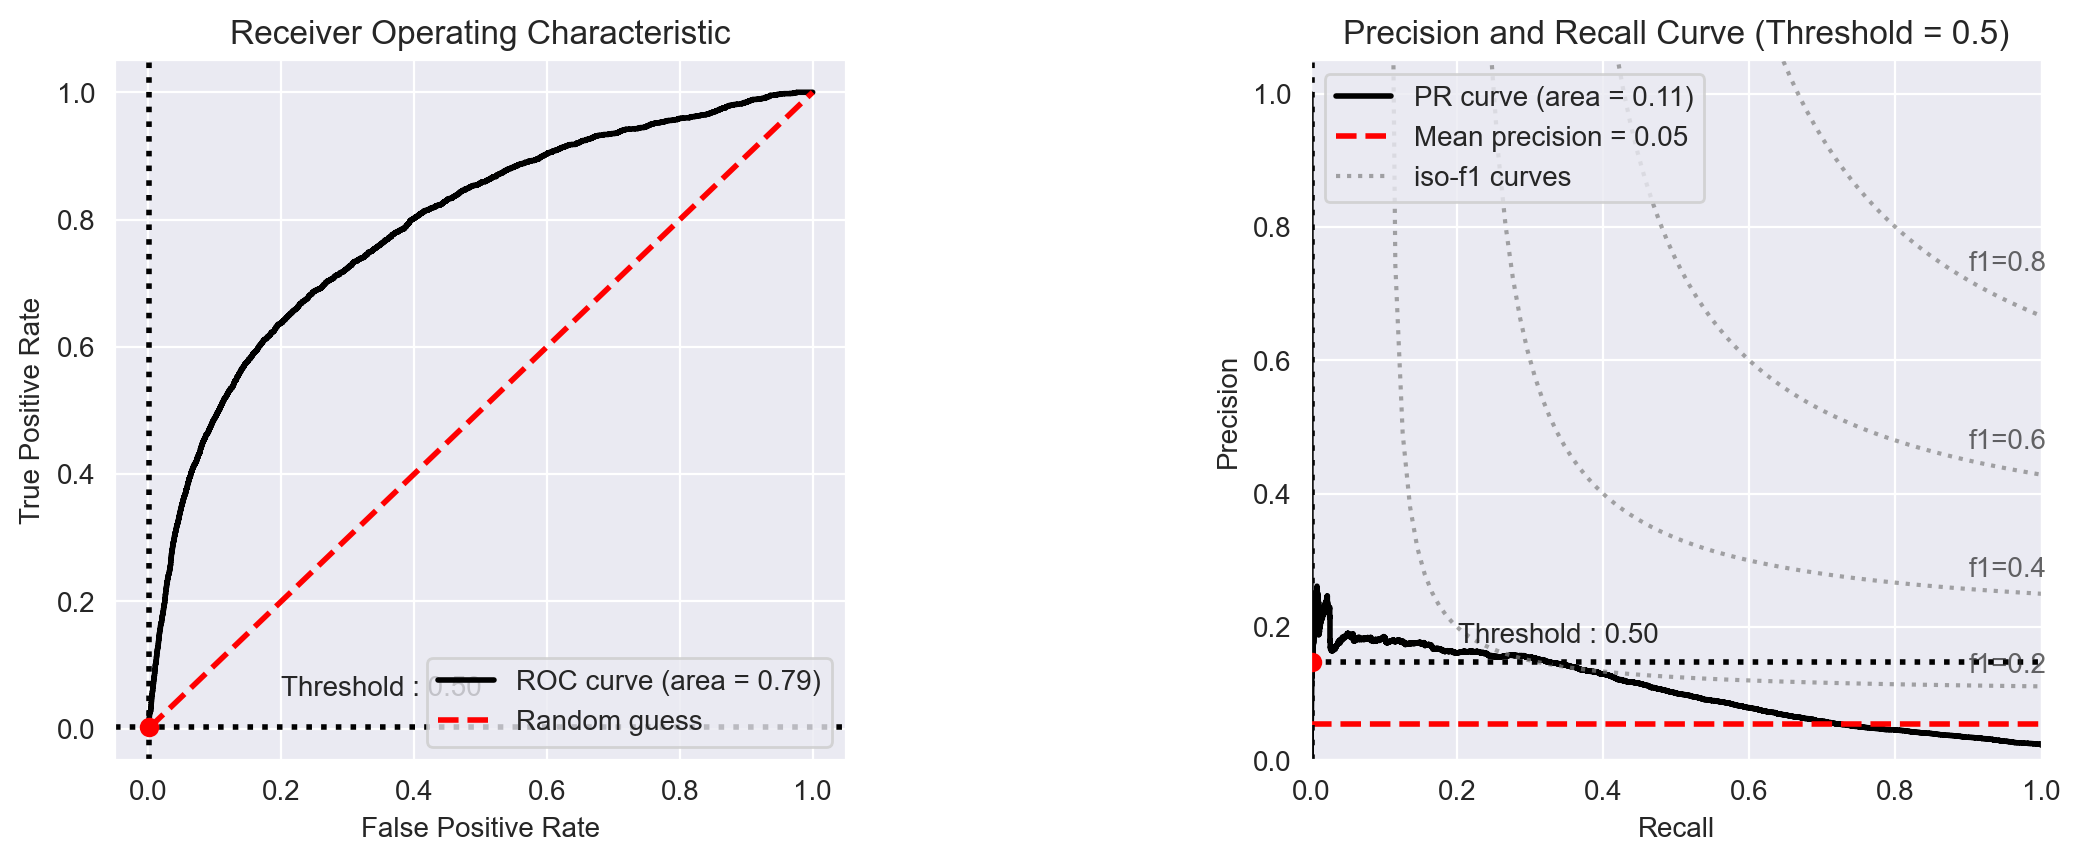

In [19]:
from plot_metric.functions import BinaryClassification
bc = BinaryClassification(yts, yhat_probas, labels=["nonSepsis", "Sepsis"])

plt.figure(figsize=(15, 10))
plt.subplot2grid(shape=(2, 6), loc=(0, 0), colspan=2)
bc.plot_roc_curve()
plt.subplot2grid((2, 6), (0, 3), colspan=2)
bc.plot_precision_recall_curve()
plt.show()

Classification report.

In [20]:
precision, recall, _ = precision_recall_curve(yts, yhat_probas)
fpr, tpr, _          = roc_curve(yts, yhat_probas)

print('f1 score  {0:.4f}:'.format(F(1, np.mean(precision), np.mean(recall))))
print('f2 score  {0:.4f}:'.format(F(2, np.mean(precision), np.mean(recall))))
print('precision {0:.4f}:'.format(precision_score(yts, yhat_ts)))
print('recall    {0:.4f}:'.format(recall_score(yts, yhat_ts)))
print('AUPRC     {0:.4f}:'.format(auc(recall, precision)))
print('AUROC     {0:.4f}:'.format(auc(fpr, tpr)))
print('Acc       {0:.4f}:'.format(accuracy_score(yts, yhat_ts)))

bc.print_report()

f1 score  0.1017:
f2 score  0.2126:
precision 0.0655:
recall    0.6620:
AUPRC     0.1056:
AUROC     0.7877:
Acc       0.7727:
                   ________________________
                  |  Classification Report |
                   ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
              precision    recall  f1-score   support

   nonSepsis       0.98      1.00      0.99    115852
      Sepsis       0.15      0.00      0.00      2757

    accuracy                           0.98    118609
   macro avg       0.56      0.50      0.50    118609
weighted avg       0.96      0.98      0.97    118609

